In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




In [2]:
df = pd.read_csv("/content/customer_churn_data.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
df.shape

(1000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [6]:
df.isna().sum().sum()

np.int64(297)

In [7]:
df["InternetService"]= df["InternetService"].fillna("")

In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [12]:
numeric_columns_data = df.select_dtypes( include = ["number"])


In [13]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


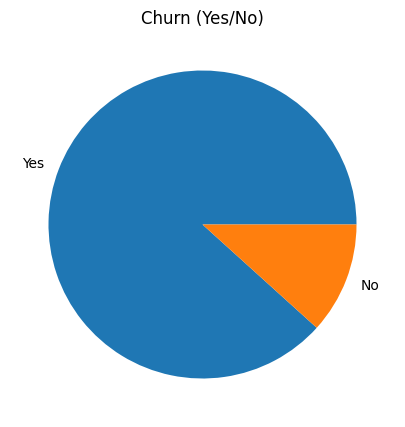

In [14]:
df["Churn"].value_counts().plot(kind="pie", figsize=(7, 5))
plt.title("Churn (Yes/No)")
plt.ylabel("")
plt.show()

In [15]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,62.54641
Yes,75.96077


In [16]:
df.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [17]:
df.groupby("Churn")["Tenure"].mean()

,Tenure
Churn,
No,30.264957
Yes,17.476784


In [18]:
df.groupby("Churn")["Age"].mean()

,Age
Churn,
No,43.487179
Yes,44.831257


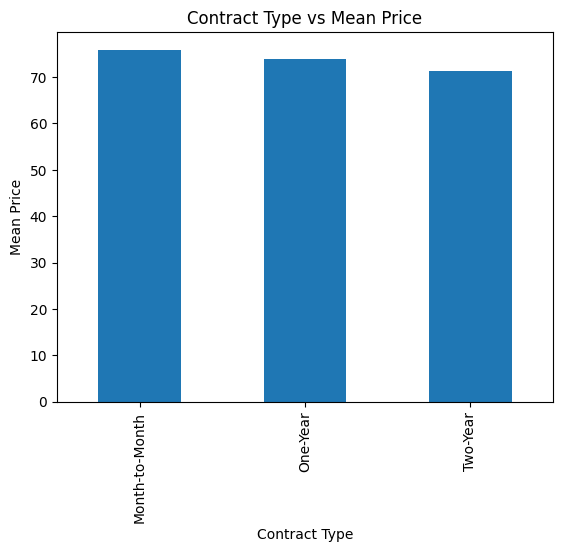

In [19]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("Mean Price")
plt.xlabel("Contract Type")
plt.title("Contract Type vs Mean Price")
plt.show()

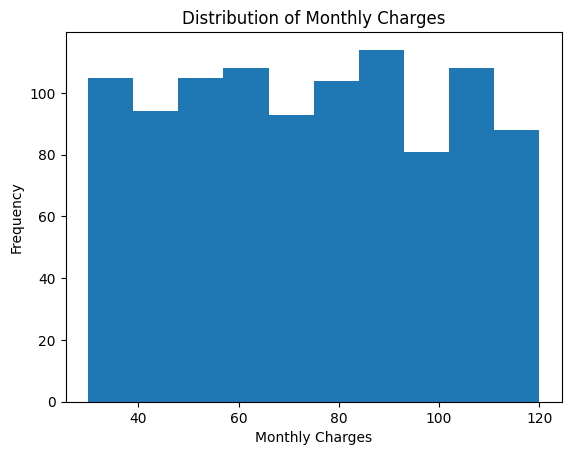

In [20]:
plt.hist(df['MonthlyCharges'])
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Charges')
plt.show()

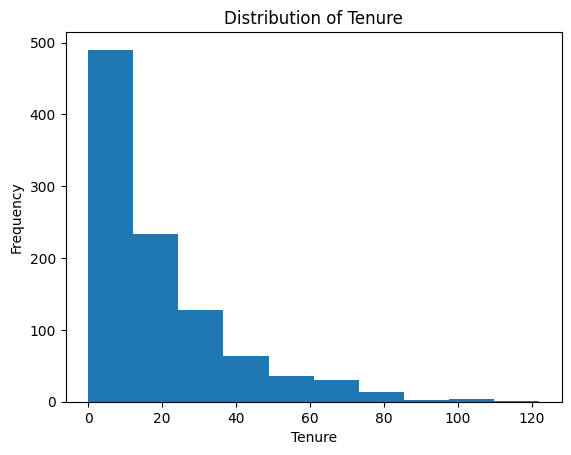

In [21]:
plt.hist(df['Tenure'])
plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

In [22]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [23]:
df.head(1)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


In [24]:
y = df[["Churn"]]
x = df[["Age","Gender","Tenure", "MonthlyCharges",]]

In [25]:
x

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [26]:
x["Gender"] = x["Gender"].apply(lambda x: 1 if x == "Male" else 0)

In [27]:
y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
x

,Age,Gender,Tenure,MonthlyCharges
0,49,1,4,88.35
1,43,1,0,36.67
2,51,0,2,63.79
3,60,0,8,102.34
4,42,1,32,69.01
...,...,...,...,...
995,42,1,41,37.14
996,62,1,9,80.93
997,51,0,15,111.72
998,39,1,68,65.67


In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)


In [31]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [32]:
x_test = scaler.fit_transform(x_test)

In [33]:
x_train

array([[-0.27936177,  1.06725697,  2.28080878,  0.92037124],
       [ 0.02664838, -0.93698147,  0.11295321,  1.12221019],
       [-0.38136516,  1.06725697,  0.69457299, -1.00540975],
       ...,
       [ 0.23065515,  1.06725697,  1.91068709,  0.16723494],
       [ 0.02664838, -0.93698147, -0.36291753,  1.6909211 ],
       [-0.38136516, -0.93698147,  0.06007868, -0.87045469]])

In [34]:
x_test

array([[ 0.57309103, -0.88640526, -1.03475948,  1.08859098],
       [ 0.98354119, -0.88640526, -0.9281382 ,  1.64456522],
       [-1.88960992,  1.12815215, -0.44834246,  1.59448733],
       [-0.5556469 , -0.88640526,  0.3513171 ,  1.42707365],
       [-1.17132214,  1.12815215, -0.71489565, -0.70799902],
       [ 0.98354119,  1.12815215, -0.55496374, -0.72773775],
       [-0.96609706, -0.88640526,  0.72449157,  0.95626838],
       [-0.96609706,  1.12815215,  0.29800647, -1.44710481],
       [ 0.67570357,  1.12815215,  0.03145328, -1.57833081],
       [-0.76087198, -0.88640526,  3.33671282,  0.86890622],
       [-0.45303436, -0.88640526, -1.03475948, -1.45478098],
       [ 0.06002834, -0.88640526,  0.19138519, -0.7500352 ],
       [ 0.88092865, -0.88640526, -0.98144884,  0.42807458],
       [-0.65825944, -0.88640526,  0.19138519,  1.47349622],
       [ 0.26525341, -0.88640526, -0.55496374, -1.55201251],
       [-0.86348452,  1.12815215, -0.28841055, -1.0066387 ],
       [ 0.16264088,  1.

In [35]:
from sklearn.metrics import accuracy_score
def modelperformance(prediction):
  print("Accuracy score on model is {}".format(accuracy_score(y_test, prediction)))

In [36]:
from sklearn.model_selection import GridSearchCV


In [37]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [38]:
y_pred = lr.predict(x_test)

In [39]:
modelperformance(y_pred)

Accuracy score on model is 0.885


In [41]:
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    "n_neighbors" : [3,5,7,9],
    "weight" : ["unifrom", "distance"],

}

In [43]:
param_grid = {
    "n_neighbors" : [3,5,7,9],
    "weights" : ["uniform", "distance"],
}
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
gridkn.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [44]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'distance'}

In [45]:
y_pred = gridkn.predict(x_test)

In [46]:
modelperformance(y_pred)

Accuracy score on model is 0.88


In [47]:
from sklearn.svm import SVC

In [49]:
svm = SVC()

param_grid = {
  "C" : [0.01,0.1,0.5,1],
  "kernel" : ["linear", "rbf", "poly"]
}

In [50]:
gridkn = GridSearchCV(SVC(), param_grid, cv=5)
gridkn.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'poly']})

In [51]:
gridkn.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [52]:
y_pred = gridkn.predict(x_test)

In [53]:
modelperformance(y_pred)

Accuracy score on model is 0.885


In [55]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
param_grid = {
    "criterion" : ["gini", "entropy"],
    "splitter" : ["best", "random"],
    "max_depth" : [None, 10, 20, 30, ],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,5]

}

In [60]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_tree.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [61]:
y_pred = grid_tree.predict(x_test)

In [62]:
modelperformance(y_pred)

Accuracy score on model is 0.89


In [63]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [67]:
param_grid = {
    "n_estimators" : [32,64,128,256],
    "max_features" : [2,3,4],
    "bootstrap" : [True, False]
}

In [68]:
grid_rfc = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_rfc.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [70]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 256}

In [71]:
y_test = grid_rfc.predict(x_test)

In [72]:
modelperformance(y_test)

Accuracy score on model is 1.0


In [74]:
best_model = grid_rfc.best_estimator_

In [75]:
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']